In [1]:
import requests
import urllib.parse
import time
from typing import Dict, List, Optional, Union, Any
from datetime import datetime, timedelta
import json

class DanishParliamentAPI:
    """
    Production-ready client for Danish Parliament Open Data API (oda.ft.dk)

    Features:
    - Comprehensive error handling
    - Automatic retry with exponential backoff
    - Built-in pagination support
    - Rate limiting protection
    - Complete type hints
    """

    def __init__(self, timeout: int = 30, retry_attempts: int = 3):
        """
        Initialize the API client.

        Args:
            timeout: Request timeout in seconds
            retry_attempts: Number of retry attempts for failed requests
        """
        self.base_url = "https://oda.ft.dk/api/"
        self.timeout = timeout
        self.retry_attempts = retry_attempts
        self.last_request_time = 0
        self.min_request_interval = 0.1  # Minimum 100ms between requests

    def _rate_limit(self) -> None:
        """Enforce rate limiting between requests."""
        elapsed = time.time() - self.last_request_time
        if elapsed < self.min_request_interval:
            time.sleep(self.min_request_interval - elapsed)
        self.last_request_time = time.time()

    def _make_request(self, url: str) -> Dict[str, Any]:
        """
        Make HTTP request with retry logic and error handling.

        Args:
            url: Complete URL to request

        Returns:
            Parsed JSON response

        Raises:
            APIError: For various API errors
            NetworkError: For network-related errors
        """
        self._rate_limit()

        for attempt in range(self.retry_attempts):
            try:
                response = requests.get(url, timeout=self.timeout)

                # Handle different HTTP status codes
                if response.status_code == 200:
                    return response.json()
                elif response.status_code == 400:
                    raise APIError(
                        f"Invalid query parameters. Check $expand and $filter syntax. "
                        f"URL: {url}"
                    )
                elif response.status_code == 404:
                    if 'api/' in url and url.count('/') == 4:  # Entity not found
                        raise EntityNotFoundError(f"Entity not found: {url}")
                    else:  # Invalid ID
                        raise RecordNotFoundError(f"Record not found: {url}")
                elif response.status_code == 501:
                    raise UnsupportedOperationError(
                        "Write operations are not supported by this API"
                    )
                else:
                    response.raise_for_status()

            except requests.exceptions.Timeout:
                if attempt < self.retry_attempts - 1:
                    wait_time = (2 ** attempt) * 1  # Exponential backoff
                    time.sleep(wait_time)
                    continue
                raise NetworkError(f"Request timed out after {self.timeout} seconds")

            except requests.exceptions.ConnectionError:
                if attempt < self.retry_attempts - 1:
                    wait_time = (2 ** attempt) * 1
                    time.sleep(wait_time)
                    continue
                raise NetworkError("Connection error - check your internet connection")

            except requests.exceptions.RequestException as e:
                raise NetworkError(f"Request failed: {str(e)}")

    def _build_url(self, entity: str, **params) -> str:
        """
        Build properly encoded URL with OData parameters.

        Args:
            entity: Entity name (e.g., 'Sag', 'Aktør')
            **params: OData parameters

        Returns:
            Complete URL with encoded parameters
        """
        # Start with base URL and entity
        url = f"{self.base_url}{entity}"

        if not params:
            return url

        # Build query parameters with proper encoding
        query_parts = []
        for key, value in params.items():
            if value is not None:
                # Ensure $ parameters are properly encoded
                if key.startswith('$'):
                    encoded_key = urllib.parse.quote(key, safe='$')
                else:
                    encoded_key = key

                encoded_value = urllib.parse.quote(str(value), safe="(),'/%")
                query_parts.append(f"{encoded_key}={encoded_value}")

        return f"{url}?{'&'.join(query_parts)}"



# Custom Exception Classes
class APIError(Exception):
    """Base exception for API errors."""
    pass

class NetworkError(APIError):
    """Network-related errors."""
    pass

class EntityNotFoundError(APIError):
    """Entity does not exist."""
    pass

class RecordNotFoundError(APIError):
    """Specific record does not exist."""
    pass

class UnsupportedOperationError(APIError):
    """Operation not supported by API."""
    pass

In [ ]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

class PartyEvolutionAnalyzer:
    def __init__(self, analyzer):
        self.analyzer = analyzer
    
    def track_party_positions_over_time(self, party, topic_keywords, months_back=12):
        """Track a party's voting positions on specific topics over time"""
        
        end_date = datetime.now()
        start_date = end_date - timedelta(days=months_back * 30)
        
        # Get voting sessions with case information
        params = {
            '$expand': 'Stemme/Aktör,Møde,Sag',
            '$filter': f"Møde/dato ge datetime'{start_date.isoformat()}' and Møde/dato le datetime'{end_date.isoformat()}'",
            '$orderby': 'Møde/dato',
            '$top': 100  # API limit
        }
        
        timeline = []
        
        # This example shows the concept - real implementation needs pagination
        url = f"{self.analyzer.base_url}Afstemning"
        response = requests.get(url, params=params)
        
        if response.status_code == 200:
            sessions = response.json().get('value', [])
            
            for session in sessions:
                # Check if session relates to topics of interest
                sag_info = session.get('Sag', {})
                sag_title = sag_info.get('titel', '').lower()
                
                if any(keyword.lower() in sag_title for keyword in topic_keywords):
                    party_votes = self.analyzer.get_party_votes_for_session(session['id'])
                    
                    if party in party_votes:
                        votes = party_votes[party]
                        total_votes = votes['for'] + votes['against']
                        
                        if total_votes > 0:
                            support_rate = votes['for'] / total_votes
                            
                            timeline.append({
                                'date': session.get('Møde', {}).get('dato'),
                                'session_id': session['id'],
                                'case_title': sag_info.get('titel'),
                                'support_rate': support_rate,
                                'votes_for': votes['for'],
                                'votes_against': votes['against'],
                                'abstentions': votes['abstain'],
                                'absent': votes['absent']
                            })
        
        return sorted(timeline, key=lambda x: x['date'])
    
    def calculate_position_drift(self, timeline, window_size=5):
        """Calculate how much a party's position has drifted over time"""
        
        if len(timeline) < window_size * 2:
            return None
        
        # Early period average
        early_positions = [entry['support_rate'] for entry in timeline[:window_size]]
        early_avg = sum(early_positions) / len(early_positions)
        
        # Recent period average
        recent_positions = [entry['support_rate'] for entry in timeline[-window_size:]]
        recent_avg = sum(recent_positions) / len(recent_positions)
        
        drift = recent_avg - early_avg
        
        return {
            'early_support': early_avg,
            'recent_support': recent_avg,
            'drift': drift,
            'interpretation': self.interpret_drift(drift)
        }
    
    def interpret_drift(self, drift):
        """Interpret the meaning of position drift"""
        if abs(drift) < 0.1:
            return "Stable position"
        elif drift > 0.3:
            return "Significant shift toward support"
        elif drift > 0.1:
            return "Moderate shift toward support"
        elif drift < -0.3:
            return "Significant shift toward opposition"
        elif drift < -0.1:
            return "Moderate shift toward opposition"
        else:
            return "Minor position adjustment"
    
    def detect_position_reversals(self, timeline, threshold=0.5):
        """Identify cases where a party completely reversed position"""
        
        reversals = []
        
        for i in range(1, len(timeline)):
            current = timeline[i]['support_rate']
            previous = timeline[i-1]['support_rate']
            
            # Check for reversal (from support to opposition or vice versa)
            if (previous >= threshold and current < (1 - threshold)) or \
               (previous < (1 - threshold) and current >= threshold):
                
                reversals.append({
                    'from_date': timeline[i-1]['date'],
                    'to_date': timeline[i]['date'],
                    'from_case': timeline[i-1]['case_title'],
                    'to_case': timeline[i]['case_title'],
                    'from_support': previous,
                    'to_support': current
                })
        
        return reversals

In [30]:
import pandas as pd
api = DanishParliamentAPI()
# Query all votings from Afstemning with pagination
all_voting_data = []
skip = 0
batch_size = 100

while True:
    votings_response = api._make_request(api._build_url('Afstemning', **{
        '$top': batch_size, 
        '$expand': 'Møde',
        '$skip': skip
    }))
    
    voting_data = votings_response.get('value', [])
    if not voting_data:
        break
    
    all_voting_data.extend(voting_data)
    skip += batch_size

votings_df = pd.DataFrame(all_voting_data)
print(f"Total votings: {len(votings_df)}")
print(votings_df.head())

Total votings: 10304
                                                Møde  id  nummer  \
0  {'id': 17, 'titel': 'Møde i salen', 'lokale': ...   1     411   
1  {'id': 18, 'titel': 'Møde i salen', 'lokale': ...   2     412   
2  {'id': 41, 'titel': 'Møde i salen', 'lokale': ...   3       1   
3  {'id': 156, 'titel': 'Møde i salen', 'lokale':...   4       7   
4  {'id': 18, 'titel': 'Møde i salen', 'lokale': ...   5     412   

                                          konklusion  vedtaget kommentar  \
0  Vedtaget\n\n108 stemmer for forslaget (V, S, D...      True      None   
1  Vedtaget\n\n98 stemmer for forslaget (V, S, DF...      True      None   
2  Vedtaget\n\n59 stemmer for forslaget (S, RV, S...      True             
3  Vedtaget\n\n72 stemmer for forslaget (S, DF, R...      True             
4  Vedtaget\n\n98 stemmer for forslaget (V, S, DF...      True             

   mødeid  typeid  sagstrinid          opdateringsdato  
0      17       2         NaN  2014-09-09T09:05:59.653  

In [31]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

class PartyEvolutionAnalyzer:
    def __init__(self, analyzer):
        self.analyzer = analyzer
    
    def track_party_positions_over_time(self, party, topic_keywords, months_back=12):
        """Track a party's voting positions on specific topics over time"""
        
        end_date = datetime.now()
        start_date = end_date - timedelta(days=months_back * 30)
        
        # Get voting sessions with case information
        params = {
            '$expand': 'Stemme/Aktör,Møde,Sag',
            '$filter': f"Møde/dato ge datetime'{start_date.isoformat()}' and Møde/dato le datetime'{end_date.isoformat()}'",
            '$orderby': 'Møde/dato',
            '$top': 100  # API limit
        }
        
        timeline = []
        
        # This example shows the concept - real implementation needs pagination
        url = f"{self.analyzer.base_url}Afstemning"
        response = requests.get(url, params=params)
        
        if response.status_code == 200:
            sessions = response.json().get('value', [])
            
            for session in sessions:
                # Check if session relates to topics of interest
                sag_info = session.get('Sag', {})
                sag_title = sag_info.get('titel', '').lower()
                
                if any(keyword.lower() in sag_title for keyword in topic_keywords):
                    party_votes = self.analyzer.get_party_votes_for_session(session['id'])
                    
                    if party in party_votes:
                        votes = party_votes[party]
                        total_votes = votes['for'] + votes['against']
                        
                        if total_votes > 0:
                            support_rate = votes['for'] / total_votes
                            
                            timeline.append({
                                'date': session.get('Møde', {}).get('dato'),
                                'session_id': session['id'],
                                'case_title': sag_info.get('titel'),
                                'support_rate': support_rate,
                                'votes_for': votes['for'],
                                'votes_against': votes['against'],
                                'abstentions': votes['abstain'],
                                'absent': votes['absent']
                            })
        
        return sorted(timeline, key=lambda x: x['date'])
    
    def calculate_position_drift(self, timeline, window_size=5):
        """Calculate how much a party's position has drifted over time"""
        
        if len(timeline) < window_size * 2:
            return None
        
        # Early period average
        early_positions = [entry['support_rate'] for entry in timeline[:window_size]]
        early_avg = sum(early_positions) / len(early_positions)
        
        # Recent period average
        recent_positions = [entry['support_rate'] for entry in timeline[-window_size:]]
        recent_avg = sum(recent_positions) / len(recent_positions)
        
        drift = recent_avg - early_avg
        
        return {
            'early_support': early_avg,
            'recent_support': recent_avg,
            'drift': drift,
            'interpretation': self.interpret_drift(drift)
        }
    
    def interpret_drift(self, drift):
        """Interpret the meaning of position drift"""
        if abs(drift) < 0.1:
            return "Stable position"
        elif drift > 0.3:
            return "Significant shift toward support"
        elif drift > 0.1:
            return "Moderate shift toward support"
        elif drift < -0.3:
            return "Significant shift toward opposition"
        elif drift < -0.1:
            return "Moderate shift toward opposition"
        else:
            return "Minor position adjustment"
    
    def detect_position_reversals(self, timeline, threshold=0.5):
        """Identify cases where a party completely reversed position"""
        
        reversals = []
        
        for i in range(1, len(timeline)):
            current = timeline[i]['support_rate']
            previous = timeline[i-1]['support_rate']
            
            # Check for reversal (from support to opposition or vice versa)
            if (previous >= threshold and current < (1 - threshold)) or \
               (previous < (1 - threshold) and current >= threshold):
                
                reversals.append({
                    'from_date': timeline[i-1]['date'],
                    'to_date': timeline[i]['date'],
                    'from_case': timeline[i-1]['case_title'],
                    'to_case': timeline[i]['case_title'],
                    'from_support': previous,
                    'to_support': current
                })
        
        return reversals

In [ ]:
import pandas as pd
api = DanishParliamentAPI()
# Query all votings from Afstemning with pagination
all_voting_data = []
skip = 0
batch_size = 100

while True:
    votings_response = api._make_request(api._build_url('Sag', **{
        '$top': batch_size, 
        '$skip': skip
    }))
    
    voting_data = votings_response.get('value', [])
    if not voting_data:
        break
    
    all_voting_data.extend(voting_data)
    skip += batch_size

votings_df = pd.DataFrame(all_voting_data)
print(f"Total votings: {len(votings_df)}")
print(votings_df.head())

In [ ]:
import pandas as pd
api = DanishParliamentAPI()
# Query all votings from Afstemning with pagination
all_voting_data = []
skip = 0
batch_size = 100

while True:
    votings_response = api._make_request(api._build_url('Afstemning', **{
        '$top': batch_size, 
        '$expand': 'Møde',
        '$skip': skip
    }))
    
    voting_data = votings_response.get('value', [])
    if not voting_data:
        break
    
    all_voting_data.extend(voting_data)
    skip += batch_size

votings_df = pd.DataFrame(all_voting_data)
print(f"Total votings: {len(votings_df)}")
print(votings_df.head())

Total votings: 10304
                                                Møde  id  nummer  \
0  {'id': 17, 'titel': 'Møde i salen', 'lokale': ...   1     411   
1  {'id': 18, 'titel': 'Møde i salen', 'lokale': ...   2     412   
2  {'id': 41, 'titel': 'Møde i salen', 'lokale': ...   3       1   
3  {'id': 156, 'titel': 'Møde i salen', 'lokale':...   4       7   
4  {'id': 18, 'titel': 'Møde i salen', 'lokale': ...   5     412   

                                          konklusion  vedtaget kommentar  \
0  Vedtaget\n\n108 stemmer for forslaget (V, S, D...      True      None   
1  Vedtaget\n\n98 stemmer for forslaget (V, S, DF...      True      None   
2  Vedtaget\n\n59 stemmer for forslaget (S, RV, S...      True             
3  Vedtaget\n\n72 stemmer for forslaget (S, DF, R...      True             
4  Vedtaget\n\n98 stemmer for forslaget (V, S, DF...      True             

   mødeid  typeid  sagstrinid          opdateringsdato  
0      17       2         NaN  2014-09-09T09:05:59.653  

In [3]:
votings_df = pd.json_normalize(all_voting_data)

In [6]:
# Create a DataFrame from the parliamentary periods data
periods_data = [
    ("1", "4. december 1849 – 4. august 1852", 101, 974),
    ("2", "4. august 1852 – 26. februar 1853", 101, 206),
    ("3", "26. februar 1853 – 27. maj 1853", 101, 90),
    ("4", "27. maj 1853 – 1. december 1854", 101, 553),
    ("5", "1. december 1854 – 14. juni 1855", 101, 195),
    ("6", "14. juni 1855 – 14. juni 1858", 101, 1096),
    ("7", "14. juni 1858 – 14. juni 1861", 101, 1096),
    ("8", "14. juni 1861 – 7. juni 1864", 101, 1089),
    ("9", "7. juni 1864 – 4. juni 1866", 101, 727),
    ("10", "4. juni 1866 – 12. oktober 1866", 102, 130),
    ("11", "12. oktober 1866 – 22. september 1869", 102, 1076),
    ("12", "22. september 1869 – 20. september 1872", 102, 1094),
    ("13", "20. september 1872 – 14. november 1873", 102, 420),
    ("14", "14. november 1873 – 25. april 1876", 102, 893),
    ("15", "25. april 1876 – 3. januar 1879", 102, 983),
    ("16", "3. januar 1879 – 24. maj 1881", 102, 872),
    ("17", "24. maj 1881 – 26. juli 1881", 102, 63),
    ("18", "26. juli 1881 – 25. juni 1884", 102, 1065),
    ("19", "25. juni 1884 – 28. januar 1887", 102, 947),
    ("20", "28. januar 1887 – 21. januar 1890", 102, 1089),
    ("21", "21. januar 1890 – 20. april 1892", 102, 820),
    ("22", "20. april 1892 – 9. april 1895", 102, 1084),
    ("23", "9. april 1895 – 5. april 1898", 114, 1092),
    ("24", "5. april 1898 – 3. april 1901", 114, 1093),
    ("25", "3. april 1901 – 16. juni 1903", 114, 804),
    ("26", "16. juni 1903 – 29. maj 1906", 114, 1078),
    ("27", "29. maj 1906 – 25. maj 1909", 114, 1092),
    ("28", "25. maj 1909 – 20. maj 1910", 114, 360),
    ("29", "20. maj 1910 – 20. maj 1913", 114, 1096),
    ("30", "20. maj 1913 – 7. maj 1915", 114, 717),
    ("31", "7. maj 1915 – 22. april 1918", 114, 1081),
    ("32", "22. april 1918 – 26. april 1920", 140, 735),
    ("33", "26. april 1920 – 6. juli 1920", 140, 71),
    ("34", "6. juli 1920 – 21. september 1920", 140, 77),
    ("35", "21. september 1920 – 11. april 1924", 149, 1298),
    ("36", "11. april 1924 – 2. december 1926", 149, 965),
    ("37", "2. december 1926 – 24. april 1929", 149, 874),
    ("38", "24. april 1929 – 16. november 1932", 149, 1302),
    ("39", "16. november 1932 – 22. oktober 1935", 149, 1070),
    ("40", "22. oktober 1935 – 3. april 1939", 149, 1259),
    ("41", "3. april 1939 – 23. marts 1943", 149, 1450),
    ("42", "23. marts 1943 – 30. oktober 1945", 149, 952),
    ("43", "30. oktober 1945 – 28. oktober 1947", 149, 728),
    ("44", "28. oktober 1947 – 5. september 1950", 150, 1043),
    ("45", "5. september 1950 – 21. april 1953", 151, 959),
    ("46", "21. april 1953 – 22. september 1953", 151, 154),
    ("47", "22. september 1953 – 14. maj 1957", 179, 1330),
    ("48", "14. maj 1957 – 15. november 1960", 179, 1281),
    ("49", "15. november 1960 – 22. september 1964", 179, 1407),
    ("50", "22. september 1964 – 22. november 1966", 179, 791),
    ("51", "22. november 1966 – 23. januar 1968", 179, 427),
    ("52", "23. januar 1968 – 21. september 1971", 179, 1337),
    ("53", "21. september 1971 – 4. december 1973", 179, 805),
    ("54", "4. december 1973 – 9. januar 1975", 179, 401),
    ("55", "9. januar 1975 – 15. februar 1977", 179, 768),
    ("56", "15. februar 1977 – 23. oktober 1979", 179, 980),
    ("57", "23. oktober 1979 – 8. december 1981", 179, 777),
    ("58", "8. december 1981 – 10. januar 1984", 179, 763),
    ("59", "10. januar 1984 – 8. september 1987", 179, 1337),
    ("60", "8. september 1987 – 10. maj 1988", 179, 245),
    ("61", "10. maj 1988 – 12. december 1990", 179, 946),
    ("62", "12. december 1990 – 21. september 1994", 179, 1379),
    ("63", "21. september 1994 – 11. marts 1998", 179, 1267),
    ("64", "11. marts 1998 – 20. november 2001", 179, 1350),
    ("65", "20. november 2001 – 8. februar 2005", 179, 1176),
    ("66", "8. februar 2005 – 13. november 2007", 179, 1008),
    ("67", "13. november 2007 – 15. september 2011", 179, 1402),
    ("68", "15. september 2011 – 18. juni 2015", 179, 1372),
    ("69", "18. juni 2015 – 5. juni 2019", 179, 1448),
    ("70", "5. juni 2019 – 1. november 2022", 179, 1232),
    ("71", "1. november 2022 – nu", 179, None),
]

periods_df = pd.DataFrame(
    periods_data,
    columns=["Period", "Date Range", "Parliamentarians", "Days"]
)
periods_df

,Period,Date Range,Parliamentarians,Days
0,1,4. december 1849 – 4. august 1852,101,974.0
1,2,4. august 1852 – 26. februar 1853,101,206.0
2,3,26. februar 1853 – 27. maj 1853,101,90.0
3,4,27. maj 1853 – 1. december 1854,101,553.0
4,5,1. december 1854 – 14. juni 1855,101,195.0
...,...,...,...,...
66,67,13. november 2007 – 15. september 2011,179,1402.0
67,68,15. september 2011 – 18. juni 2015,179,1372.0
68,69,18. juni 2015 – 5. juni 2019,179,1448.0
69,70,5. juni 2019 – 1. november 2022,179,1232.0


In [14]:
# Convert Møde.dato to datetime
votings_df['Møde.dato'] = pd.to_datetime(votings_df['Møde.dato'])

# Create a mapping of Danish months to English
danish_months = {
    'januar': 'January', 'februar': 'February', 'marts': 'March',
    'april': 'April', 'maj': 'May', 'juni': 'June',
    'juli': 'July', 'august': 'August', 'september': 'September',
    'oktober': 'October', 'november': 'November', 'december': 'December'
}

def parse_date_range(date_range):
    dates = date_range.split(' – ')
    return dates[0].strip(), dates[1].strip()

def convert_danish_to_english(date_str):
    """Convert Danish month names to English."""
    for danish, english in danish_months.items():
        date_str = date_str.replace(danish, english)
    return date_str

# Create a mapping of periods with their date ranges
periods_df['start_date'] = periods_df['Date Range'].apply(lambda x: parse_date_range(x)[0])
periods_df['end_date'] = periods_df['Date Range'].apply(lambda x: parse_date_range(x)[1])

# Convert to datetime
periods_df['start_date'] = periods_df['start_date'].apply(
    lambda x: pd.to_datetime(convert_danish_to_english(x), format='%d. %B %Y', errors='coerce')
)
periods_df['end_date'] = periods_df['end_date'].apply(
    lambda x: pd.Timestamp.now() if x == 'nu' else pd.to_datetime(convert_danish_to_english(x), format='%d. %B %Y', errors='coerce')
)

# Function to find the period for a given date
def find_period(vote_date):
    for _, period in periods_df.iterrows():
        if period['start_date'] <= vote_date <= period['end_date']:
            return period['Period']
    return None

# Add period column
votings_df['Period'] = votings_df['Møde.dato'].apply(find_period)


In [21]:
votings_df.to_csv('votings.csv', index=False)
print("votings_df saved to 'votings.csv'")

votings_df saved to 'votings.csv'


In [ ]:
votings_df

<Axes: xlabel='Period'>

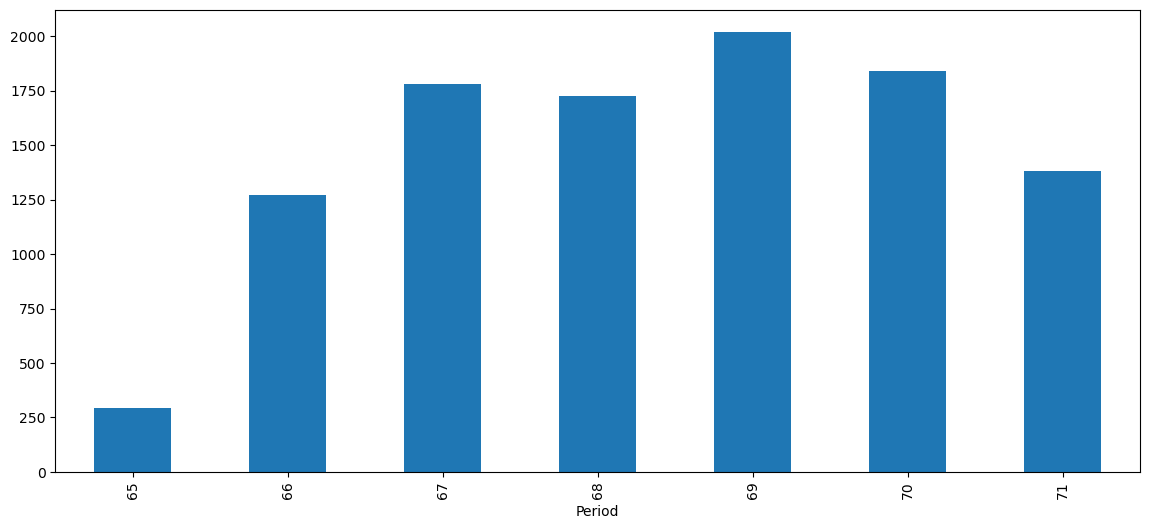

In [15]:
votings_df['Period'].value_counts().sort_index().plot(kind='bar', figsize=(14, 6))

In [16]:
def get_ids_by_period(period: int) -> List[int]:
    """
    Get all voting IDs for a given parliamentary period.
    
    Args:
        period: Period number (1-71)
    
    Returns:
        List of voting IDs in that period
    """
    period_str = str(period)
    return votings_df[votings_df['Period'] == period_str]['id'].tolist()

In [20]:
get_ids_by_period(65)

[5973,
 5977,
 5978,
 5979,
 5980,
 5981,
 5982,
 5983,
 5984,
 5985,
 5986,
 5987,
 5988,
 5989,
 5990,
 5991,
 5992,
 5993,
 5994,
 5995,
 5996,
 5997,
 5998,
 5999,
 6000,
 6001,
 6002,
 6003,
 6004,
 6005,
 6006,
 6007,
 6008,
 6009,
 6010,
 6011,
 6012,
 6013,
 6014,
 6015,
 6016,
 6017,
 6018,
 6019,
 6020,
 6021,
 6022,
 6023,
 6024,
 6025,
 6026,
 6027,
 6028,
 6029,
 6030,
 6031,
 6032,
 6033,
 6034,
 6035,
 6036,
 6037,
 6038,
 6039,
 6040,
 6041,
 6042,
 6043,
 6044,
 6045,
 6046,
 6047,
 6048,
 6049,
 6050,
 6051,
 6052,
 6053,
 6054,
 6055,
 6056,
 6057,
 6058,
 6059,
 6060,
 6061,
 6062,
 6063,
 6064,
 6065,
 6066,
 6067,
 6068,
 6069,
 6070,
 6071,
 6072,
 6073,
 6074,
 6075,
 6076,
 6077,
 6078,
 6079,
 6080,
 6081,
 6082,
 6083,
 6084,
 6085,
 6086,
 6087,
 6088,
 6089,
 6090,
 6091,
 6092,
 6093,
 6094,
 6095,
 6096,
 6097,
 6098,
 6099,
 6100,
 6101,
 6102,
 6103,
 6104,
 6105,
 6106,
 6107,
 6108,
 6109,
 6110,
 6111,
 6112,
 6113,
 6114,
 6115,
 6116,
 6117,
 6118,